# Solve DS-MFG problem using Gurobi PoolSearch

In [1]:
from solve_gurobi_pool import (
    solve_gurobi_pool,
    load_gurobi_pool_results,
    create_flattened_dataframe,
    print_run_info,
    group_by_objective,
    print_solution_analysis,
    aggregate_pool_run_timings,
)
import os
from pathlib import Path
import matplotlib.pyplot as plt

In [ ]:
# Build and solve the model using Gurobi's PoolSearch feature

# Set up paths
script_dir = Path().parent
result_dir = script_dir / "result_gurobi"

# Solve with pool search
result_dict = solve_gurobi_pool(
    pool_search_mode=2,
    pool_solutions=30,
    verbose=True,
    save=True
)

Read LP format model from file /tmp/tmp7m9u5qdl.lp
Reading time = 0.00 seconds
capex: 20 rows, 19 columns, 58 nonzeros
Set parameter PoolSearchMode to value 0
Set parameter PoolSolutions to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 22.04.3 LTS")

CPU model: 13th Gen Intel(R) Core(TM) i7-1365U, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
PoolSolutions  1

Optimize a model with 20 rows, 19 columns and 58 nonzeros
Model fingerprint: 0x17eef36d
Variable types: 0 continuous, 19 integer (19 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e-02, 1e+01]


  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+00]
Found heuristic solution: objective 22.9099000
Presolve removed 20 rows and 19 columns
Presolve time: 0.00s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.02 seconds (0.00 work units)
Thread count was 1 (of 12 available processors)

Solution count 1: 11.7095 

Optimal solution found (tolerance 1.00e-04)
Best objective 1.170950000000e+01, best bound 1.170950000000e+01, gap 0.0000%
Solve time: 0.026567935943603516 seconds

Number of solutions in pool: 1
Solution 1: Objective: 11.709500
{'solution_id': 1, 'ip_obj_value': 11.7095, 'values': {'f(f01)': 0.0, 'f(f02)': 0.0, 'f(f03)': 1.0, 'f(f06)': 0.0, 'f(f08)': 0.0, 'f(f09)': 0.0, 'f(f10)': 1.0, 'f(f11)': 1.0, 'f(f13)': 1.0, 'f(f14)': 0.0, 'f(f15)': 0.0, 'f(f16)': 0.0, 'f(f17)': 1.0, 'f(f00)': 1.0, 'f(f04)': 1.0, 'f(f05)': 1.0, 'f(f07)': 1.0, 'f(f12)': 1.0, 'f(f18)': 1.0}}

All 1 solutions saved to: /home/yirangpark/repos/secquoia/pd_is

# Import Gurobi PoolSearch Run for Analysis

In [2]:
# Load data
import_dir = './result_gurobi'
# Update this path to your desired result file
gpool_path = os.path.join(import_dir, 'gurobi_pool_solutions_n100_20260126_105949.json')

gpool_data = load_gurobi_pool_results(gpool_path)
run_info = gpool_data['run_info']
solutions = gpool_data['solutions']

# Print run info
print(f"Loaded {len(solutions)} solutions\n")
print_run_info(run_info)

# Create flattened DataFrame
gpool_flat = create_flattened_dataframe(solutions)

print(f"\nFlattened DataFrame shape: {gpool_flat.shape}")
print(f"Columns: {list(gpool_flat.columns)}")

# Group by objective value
obj_groups = group_by_objective(gpool_flat)

print(f"Number of unique objective values: {len(obj_groups)}")

Loaded 36 solutions

Run Info:
  Model: capex
  Variables: 19
  Constraints: 20
  Solve Time: 0.01 seconds
  Solutions Found: 36

Flattened DataFrame shape: (36, 21)
Columns: ['solution_id', 'ip_obj_value', 'ff01', 'ff02', 'ff03', 'ff06', 'ff08', 'ff09', 'ff10', 'ff11', 'ff13', 'ff14', 'ff15', 'ff16', 'ff17', 'ff00', 'ff04', 'ff05', 'ff07', 'ff12', 'ff18']
Number of unique objective values: 36


In [3]:
# Analyze solutions to distinguish duplicates vs same objective
print_solution_analysis(gpool_flat)


SOLUTION ANALYSIS

1. DUPLICATE SOLUTIONS (same variable values AND same objective):
   Total solutions with duplicate variable combinations: 0
   Unique variable combinations: 36
   No true duplicate solutions found

2. SAME OBJECTIVE, DIFFERENT VARIABLES:
   Objective values with multiple variable combinations: 0

3. UNIQUE SOLUTIONS (unique in both objective and variables):
   Count: 36


{'analysis': {'duplicate_solutions': {},
  'same_obj_different_vars': {},
  'unique_solutions': [{'solution_id': 15,
    'obj_value': 16.63,
    'variable_signature': (0.0,
     0.0,
     1.0,
     0.0,
     0.0,
     0.0,
     1.0,
     1.0,
     0.0,
     0.0,
     0.0,
     1.0,
     0.0,
     1.0,
     1.0,
     1.0,
     1.0,
     0.0,
     1.0)},
   {'solution_id': 3,
    'obj_value': 12.24,
    'variable_signature': (0.0,
     0.0,
     1.0,
     0.0,
     0.0,
     0.0,
     1.0,
     1.0,
     0.0,
     0.0,
     1.0,
     0.0,
     1.0,
     1.0,
     1.0,
     1.0,
     1.0,
     1.0,
     1.0)},
   {'solution_id': 2,
    'obj_value': 11.81,
    'variable_signature': (0.0,
     0.0,
     1.0,
     0.0,
     0.0,
     0.0,
     1.0,
     1.0,
     0.0,
     1.0,
     0.0,
     0.0,
     1.0,
     1.0,
     1.0,
     1.0,
     1.0,
     1.0,
     1.0)},
   {'solution_id': 1,
    'obj_value': 11.71,
    'variable_signature': (0.0,
     0.0,
     1.0,
     -0.0,
     -0.0,
     

### Plot (# Solutions Found) vs (# PoolSearch Solution Count Setpoint)

,n,solve_time,solution_count
0,5,0.061645,5
1,10,0.061138,10
2,20,0.067194,20
3,30,0.043471,30
4,36,0.073284,36
5,37,0.073679,36
6,50,0.008868,36
7,100,0.006877,36
8,100,0.010348,36


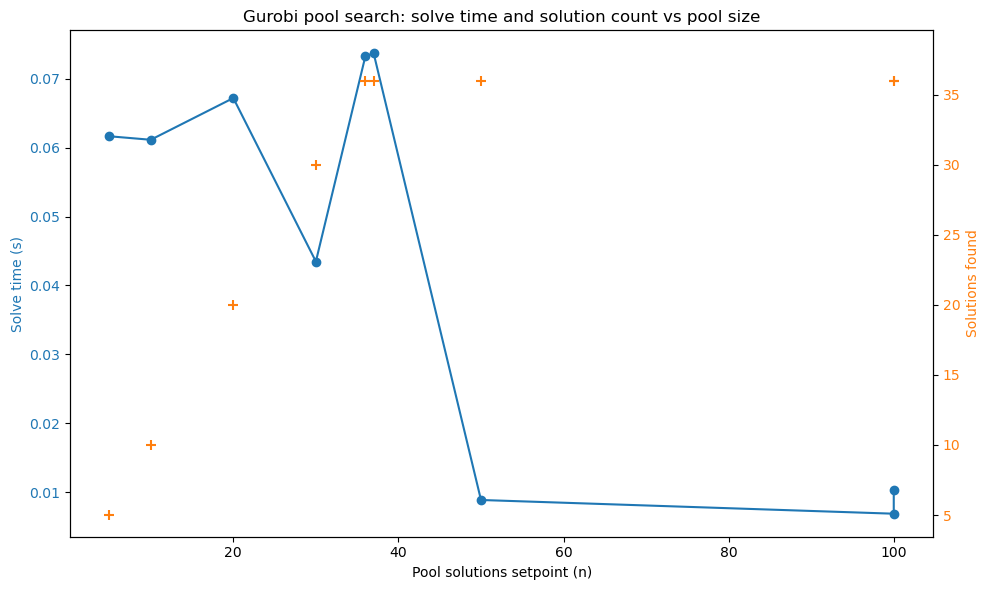

In [9]:
# Aggregate solve time vs pool-solutions setpoint from all gurobi_pool_solutions_n*.json files
df = aggregate_pool_run_timings()
display(df)

if len(df) > 0:
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.plot(df["n"], df["solve_time"], "o-", markersize=6, color="C0")
    ax1.set_xlabel("Pool solutions setpoint (n)")
    ax1.set_ylabel("Solve time (s)", color="C0")
    ax1.tick_params(axis="y", labelcolor="C0")

    ax2 = ax1.twinx()
    ax2.scatter(df["n"], df["solution_count"], marker="+", s=50, color="C1", zorder=5)
    ax2.set_ylabel("Solutions found", color="C1")
    if len(df) > 0:
        ax2.set_ylim(top=max(df["solution_count"]) * 1.1)
    ax2.tick_params(axis="y", labelcolor="C1")

    plt.title("Gurobi pool search: solve time and solution count vs pool size")
    fig.tight_layout()
    plt.show()
else:
    print("No result files found matching pattern 'gurobi_pool_solutions_n*.json'")